# BBBM-AD Prevalence by Age Across Hypothesized Durations

Reads the pre-computed consistent-rate artifacts (from `bbbm_duration_consistent_rates.ipynb`)
and plots **total-population BBBM-AD prevalence by age group**, with one line per Weibull scale
value. Separate panels for Female and Male.

**BBBM total-population prevalence** = `prevalence_any × bbbm_conditional_prevalence`

- `prevalence_any`: GBD-fitted probability of being in *any* AD state (BBBM + MCI + Dementia)
- `bbbm_conditional_prevalence`: MCMC-refitted probability of being in BBBM *given* any AD state

The MCMC fitting holds total-population *dementia* prevalence approximately constant,
so longer BBBM duration forces a larger BBBM share — we expect **higher BBBM prevalence
at every age** as scale increases.

In [1]:
import os

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import scipy.stats
from vivarium.framework.artifact import Artifact

# --- Paths ---
BASE_ARTIFACT = '../united_states_of_america.hdf'
ARTIFACT_DIR  = '../artifacts_sweep'

# --- Weibull shape (fixed) ---
WEIBULL_SHAPE = 1.22
DEFAULT_SCALE = 6.76

In [2]:
# All scale values for which consistent-rate artifacts exist
SWEEP_VALUES = [3, 4, 5, 6, 6.76, 8, 9, 10, 12, 15, 18, 21, 25, 30]

# Map each scale to its artifact path
artifact_paths = {}
for s in SWEEP_VALUES:
    if s == DEFAULT_SCALE:
        path = os.path.abspath(BASE_ARTIFACT)
    else:
        path = os.path.join(ARTIFACT_DIR, f'artifact_scale_{s}.hdf')
    if not os.path.exists(path):
        raise FileNotFoundError(f'Artifact missing for scale={s}: {path}')
    artifact_paths[s] = path

# Print summary
print(f'{"Scale":>7s}  {"Mean dur (yr)":>13s}  {"Artifact"}')
print('-' * 60)
for s in SWEEP_VALUES:
    dur = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=s).mean()
    marker = ' *' if s == DEFAULT_SCALE else ''
    print(f'{s:>7.2f}  {dur:>13.2f}  {os.path.basename(artifact_paths[s])}{marker}')

  Scale  Mean dur (yr)  Artifact
------------------------------------------------------------
   3.00           2.81  artifact_scale_3.hdf
   4.00           3.75  artifact_scale_4.hdf
   5.00           4.68  artifact_scale_5.hdf
   6.00           5.62  artifact_scale_6.hdf
   6.76           6.33  united_states_of_america.hdf *
   8.00           7.49  artifact_scale_8.hdf
   9.00           8.43  artifact_scale_9.hdf
  10.00           9.37  artifact_scale_10.hdf
  12.00          11.24  artifact_scale_12.hdf
  15.00          14.05  artifact_scale_15.hdf
  18.00          16.86  artifact_scale_18.hdf
  21.00          19.67  artifact_scale_21.hdf
  25.00          23.42  artifact_scale_25.hdf
  30.00          28.10  artifact_scale_30.hdf


In [3]:
def load_bbbm_prevalence(artifact_path):
    """
    Load BBBM total-population prevalence from a consistent-rate artifact.

    Returns a DataFrame indexed by (sex, age_start) with columns:
      age_mid   - midpoint of age group
      mean      - mean across 500 draws
      lo        - 2.5th percentile across draws
      hi        - 97.5th percentile across draws
    """
    art = Artifact(artifact_path)
    p_any   = art.load('cause.alzheimers_consistent.prevalence_any')
    bbbm_c  = art.load('cause.alzheimers_consistent.bbbm_conditional_prevalence')

    # Total-population BBBM prevalence = p_any * bbbm_conditional
    bbbm_prev = p_any * bbbm_c  # element-wise; same index

    draw_cols = [c for c in bbbm_prev.columns if c.startswith('draw_')]

    rows = []
    for (sex, age_start, age_end, year_start, year_end), row in bbbm_prev.iterrows():
        vals = row[draw_cols].values.astype(float)
        rows.append({
            'sex':      sex,
            'age_start': age_start,
            'age_end':   age_end,
            'age_mid':   0.5 * (age_start + min(age_end, 105)),  # cap 100+ at midpoint ~102.5
            'mean':      vals.mean(),
            'lo':        np.percentile(vals, 2.5),
            'hi':        np.percentile(vals, 97.5),
        })

    df = pd.DataFrame(rows).sort_values(['sex', 'age_start']).reset_index(drop=True)
    return df


# Load all artifacts
print('Loading artifacts...')
data = {}
for scale in SWEEP_VALUES:
    data[scale] = load_bbbm_prevalence(artifact_paths[scale])
    dur = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale).mean()
    # Quick sanity: female peak prevalence
    female = data[scale][data[scale]['sex'] == 'Female']
    peak_age = female.loc[female['mean'].idxmax(), 'age_start']
    peak_val = female['mean'].max()
    print(f'  scale={scale:>5.2f} ({dur:>5.1f} yr mean): '
          f'female peak {peak_val:.4f} at age {peak_age}')

print('Done.')

Loading artifacts...


  scale= 3.00 (  2.8 yr mean): female peak 0.0591 at age 90


  scale= 4.00 (  3.7 yr mean): female peak 0.0857 at age 90


  scale= 5.00 (  4.7 yr mean): female peak 0.1304 at age 85


  scale= 6.00 (  5.6 yr mean): female peak 0.1504 at age 85


...

  scale=15.00 ( 14.1 yr mean): female peak 0.3638 at age 85


  scale=18.00 ( 16.9 yr mean): female peak 0.4309 at age 85


  scale=21.00 ( 19.7 yr mean): female peak 0.5023 at age 85


  scale=25.00 ( 23.4 yr mean): female peak 0.6678 at age 85


  scale=30.00 ( 28.1 yr mean): female peak 0.7125 at age 85
Done.


In [4]:
# Color scheme: sequential colormap indexed by log(scale) so short/long are clearly separated
log_scales = np.log(SWEEP_VALUES)
norm = mcolors.Normalize(vmin=log_scales.min(), vmax=log_scales.max())
cmap = cm.get_cmap('plasma_r')   # dark = short duration, light = long duration

def scale_color(s):
    return cmap(norm(np.log(s)))

def scale_label(s):
    dur = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=s).mean()
    marker = ' (default)' if s == DEFAULT_SCALE else ''
    return f'scale={s} ({dur:.1f} yr){marker}'

/tmp/ipykernel_1559/418697353.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma_r')   # dark = short duration, light = long duration


/tmp/ipykernel_1559/2071515233.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


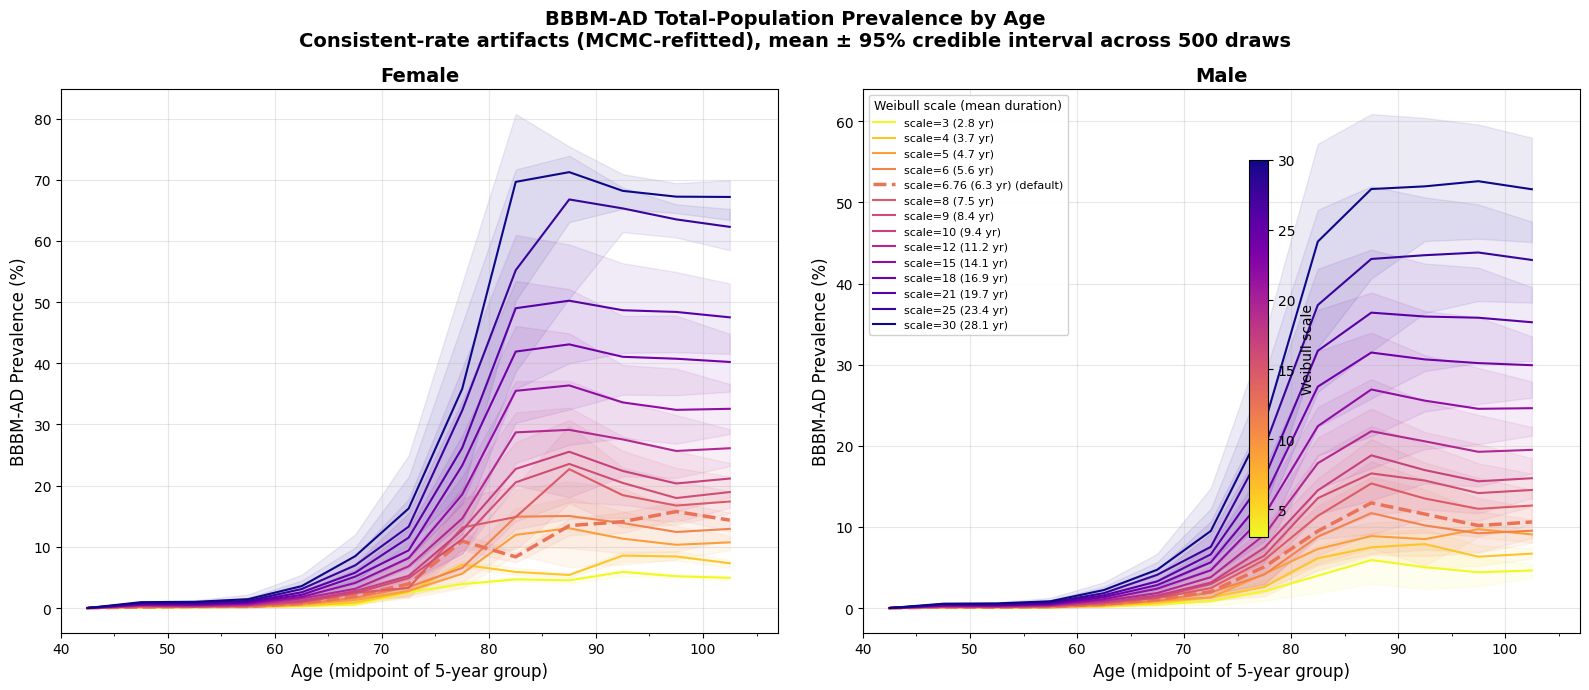

Figure saved to ../bbbm_prevalence_by_age.png


In [5]:
# --- Main figure: 2 panels, Female | Male ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

for ax, sex in zip(axes, ['Female', 'Male']):
    for scale in SWEEP_VALUES:
        sub = data[scale][data[scale]['sex'] == sex].sort_values('age_start')
        # Only plot ages where prevalence is non-negligible
        sub = sub[sub['age_start'] >= 40]

        color = scale_color(scale)
        lw = 2.5 if scale == DEFAULT_SCALE else 1.5
        ls = '--' if scale == DEFAULT_SCALE else '-'

        ax.plot(sub['age_mid'], sub['mean'] * 100,
                color=color, linewidth=lw, linestyle=ls,
                label=scale_label(scale))
        # 95% credible interval as a shaded band
        ax.fill_between(sub['age_mid'],
                         sub['lo'] * 100, sub['hi'] * 100,
                         color=color, alpha=0.08)

    ax.set_xlabel('Age (midpoint of 5-year group)', fontsize=12)
    ax.set_ylabel('BBBM-AD Prevalence (%)', fontsize=12)
    ax.set_title(sex, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(40, 107)
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(5))

# Single shared legend on the right panel
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, fontsize=8, loc='upper left',
               framealpha=0.9, title='Weibull scale (mean duration)', title_fontsize=9)

# Colorbar to show the scale → color mapping continuously
sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(
    vmin=min(SWEEP_VALUES), vmax=max(SWEEP_VALUES)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.02, label='Weibull scale')
cbar.ax.yaxis.set_label_position('right')

fig.suptitle(
    'BBBM-AD Total-Population Prevalence by Age\n'
    'Consistent-rate artifacts (MCMC-refitted), mean ± 95% credible interval across 500 draws',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../bbbm_prevalence_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to ../bbbm_prevalence_by_age.png')

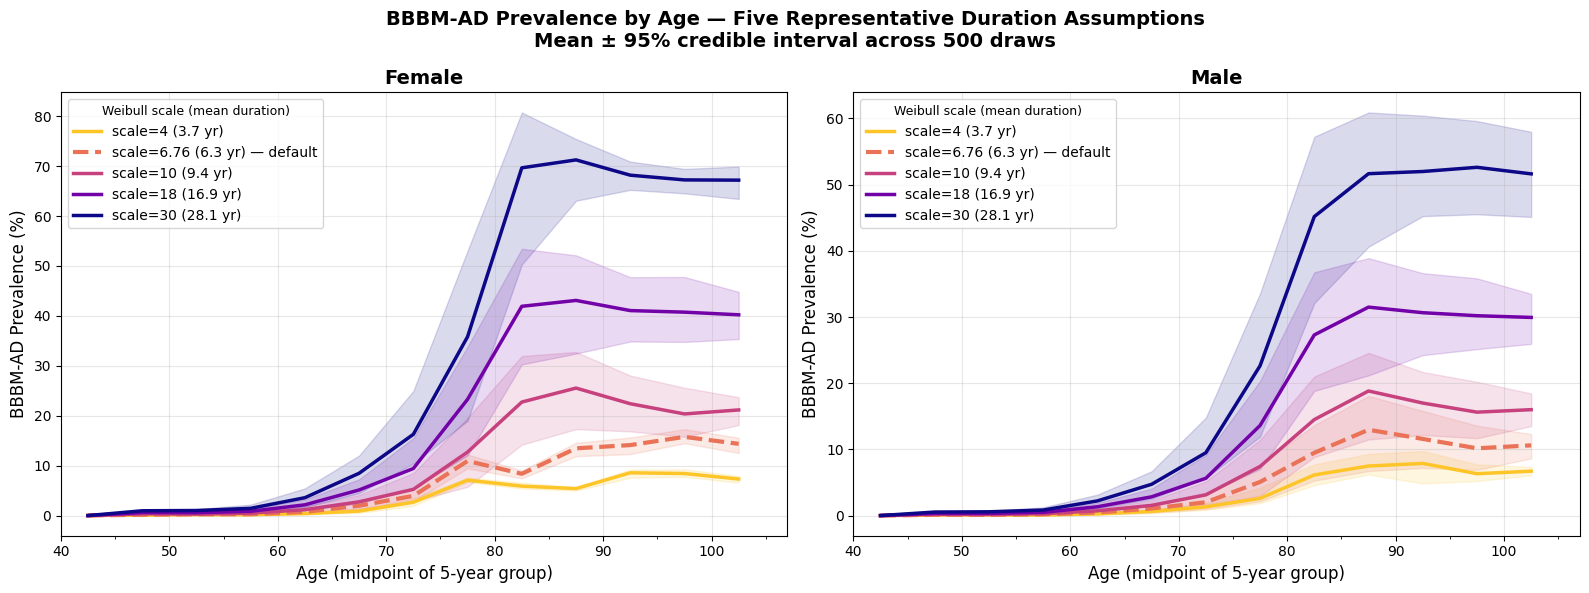

Figure saved to ../bbbm_prevalence_by_age_highlight.png


In [6]:
# --- Detail figure: highlight a few representative scales ---
# With 14 lines the main figure is dense; this shows 5 representative scales more clearly.
highlight_scales = [4, 6.76, 10, 18, 30]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, sex in zip(axes, ['Female', 'Male']):
    for scale in highlight_scales:
        sub = data[scale][data[scale]['sex'] == sex].sort_values('age_start')
        sub = sub[sub['age_start'] >= 40]
        dur = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale).mean()
        color = scale_color(scale)
        lw = 3.0 if scale == DEFAULT_SCALE else 2.5
        ls = '--' if scale == DEFAULT_SCALE else '-'
        label = f'scale={scale} ({dur:.1f} yr)'
        if scale == DEFAULT_SCALE:
            label += ' — default'

        ax.plot(sub['age_mid'], sub['mean'] * 100,
                color=color, linewidth=lw, linestyle=ls, label=label)
        ax.fill_between(sub['age_mid'],
                         sub['lo'] * 100, sub['hi'] * 100,
                         color=color, alpha=0.15)

    ax.set_xlabel('Age (midpoint of 5-year group)', fontsize=12)
    ax.set_ylabel('BBBM-AD Prevalence (%)', fontsize=12)
    ax.set_title(sex, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, title='Weibull scale (mean duration)', title_fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(40, 107)
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(5))

fig.suptitle(
    'BBBM-AD Prevalence by Age — Five Representative Duration Assumptions\n'
    'Mean ± 95% credible interval across 500 draws',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../bbbm_prevalence_by_age_highlight.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to ../bbbm_prevalence_by_age_highlight.png')

In [7]:
# --- Summary table: female BBBM prevalence at key ages ---
key_ages = [50, 60, 65, 70, 75, 80, 85, 90]

print('Female BBBM-AD Prevalence (%) at key ages — mean across 500 draws')
print()

hdr = f'{"Scale":>7s}  {"Mean dur":>8s}  ' + '  '.join(f'{"Age " + str(a):>7s}' for a in key_ages)
print(hdr)
print('-' * len(hdr))

for scale in SWEEP_VALUES:
    dur = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale).mean()
    female = data[scale][data[scale]['sex'] == 'Female'].set_index('age_start')
    vals = []
    for age in key_ages:
        if age in female.index:
            vals.append(f'{female.loc[age, "mean"] * 100:>7.2f}')
        else:
            vals.append(f'{"—":>7s}')
    marker = ' *' if scale == DEFAULT_SCALE else ''
    print(f'{scale:>7.2f}  {dur:>8.2f}  ' + '  '.join(vals) + marker)

print()
print('Male BBBM-AD Prevalence (%) at key ages — mean across 500 draws')
print()
print(hdr)
print('-' * len(hdr))

for scale in SWEEP_VALUES:
    dur = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale).mean()
    male = data[scale][data[scale]['sex'] == 'Male'].set_index('age_start')
    vals = []
    for age in key_ages:
        if age in male.index:
            vals.append(f'{male.loc[age, "mean"] * 100:>7.2f}')
        else:
            vals.append(f'{"—":>7s}')
    marker = ' *' if scale == DEFAULT_SCALE else ''
    print(f'{scale:>7.2f}  {dur:>8.2f}  ' + '  '.join(vals) + marker)

Female BBBM-AD Prevalence (%) at key ages — mean across 500 draws

  Scale  Mean dur   Age 50   Age 60   Age 65   Age 70   Age 75   Age 80   Age 85   Age 90
-----------------------------------------------------------------------------------------
   3.00      2.81     0.09     0.29     0.58     2.56     3.91     4.68     4.53     5.91
   4.00      3.75     0.17     0.39     0.89     2.67     7.10     5.90     5.40     8.57
   5.00      4.68     0.17     0.61     1.32     2.81     5.60    11.96    13.04    11.33
   6.00      5.62     0.19     0.69     1.67     3.43     6.56    14.93    15.04    13.89
   6.76      6.33     0.26     0.74     1.97     3.94    10.94     8.37    13.47    14.12 *
   8.00      7.49     0.24     0.91     2.48     3.28    13.16    14.87    22.70    18.44
   9.00      8.43     0.26     1.06     2.44     4.88    11.26    20.55    23.55    20.45
  10.00      9.37     0.29     1.18     2.76     5.25    12.72    22.74    25.54    22.40
  12.00     11.24     0.38     

## Notes

### What the MCMC fitting constrains

For each scale value the MCMC re-fits the susceptible-to-BBBM transition rate
(`h_S_to_BBBM`) to maintain ODE consistency with the **same observed dementia
prevalence and incidence** (from GBD). This keeps total-population *dementia* prevalence
approximately constant, while allowing `prevalence_any` (= BBBM + MCI + Dementia) to
rise as scale increases — because the larger BBBM share requires more people to be in the
disease pool overall.

Consequently, BBBM prevalence at any age reflects both:
1. The **larger BBBM conditional share** (BBBM|diseased fraction) at longer duration
2. The **higher overall disease prevalence** (`p_any`) that the MCMC has fitted

### Credible intervals

Shaded bands show the 2.5th–97.5th percentile range across 500 MCMC draws.
The bands reflect uncertainty in the GBD-fitted transition rates, not BBBM duration
uncertainty (each scale value is treated as a point assumption).